# Vanishing Gradient Problem

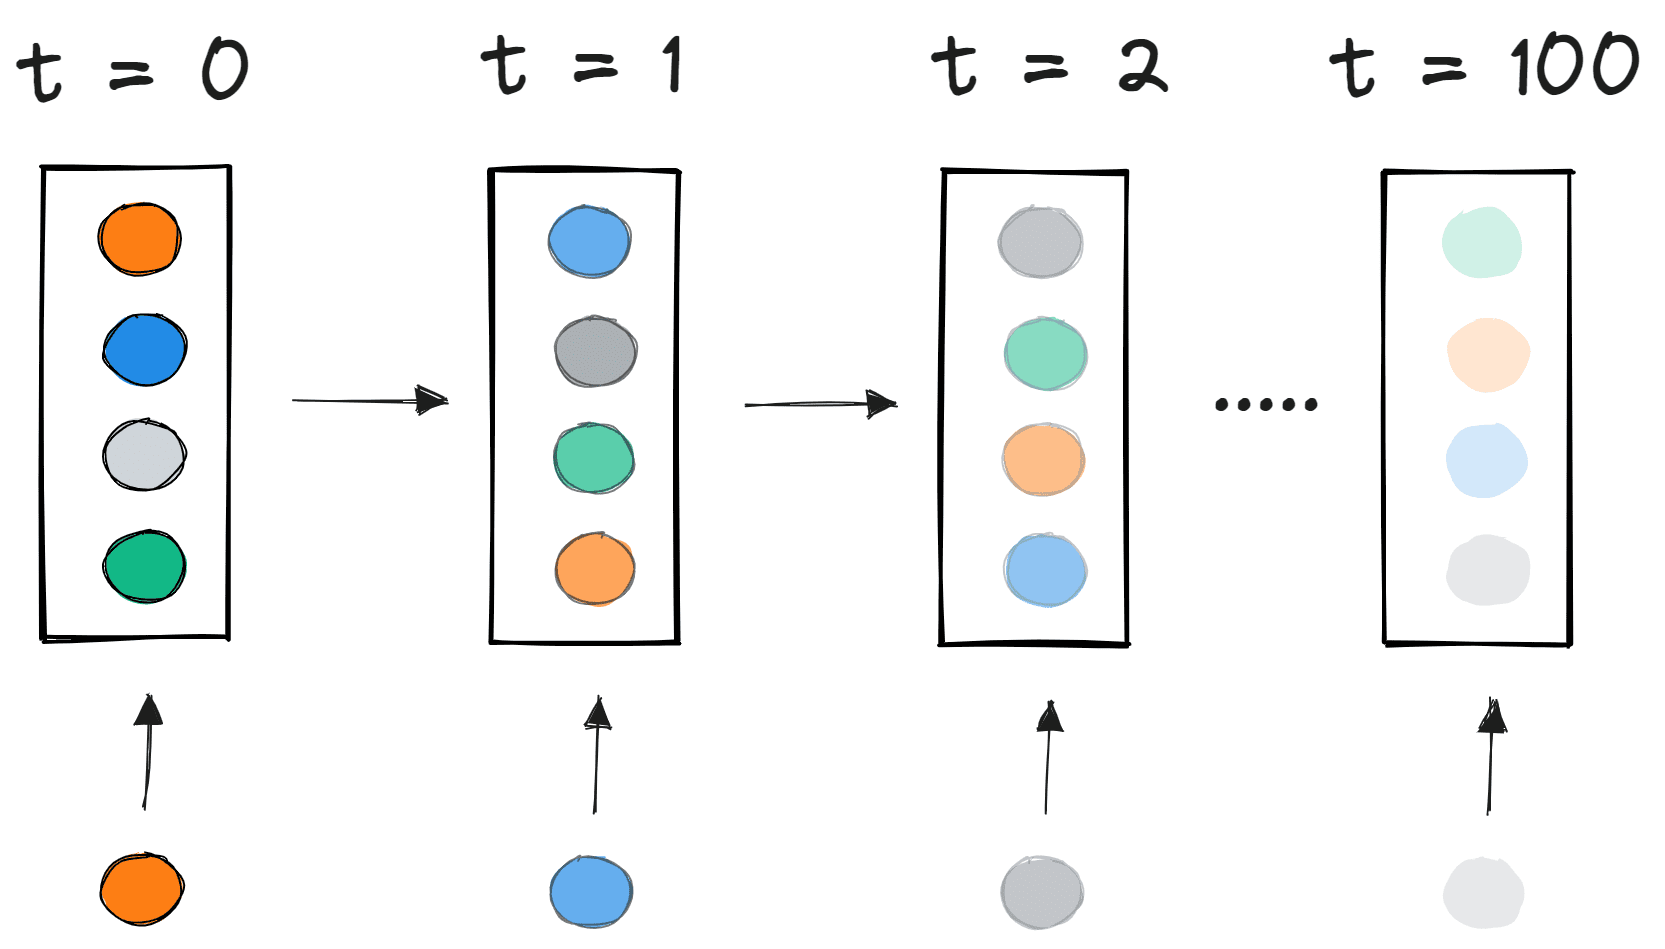

https://medium.com/@El_Fares_Anass/a-basic-explanation-how-the-gradient-descent-is-determined-during-back-propagation-864376f8f1a4

https://www.kdnuggets.com/2022/02/vanishing-gradient-problem.html

https://kharshit.github.io/blog/2019/01/04/the-gradient-problem-in-rnn



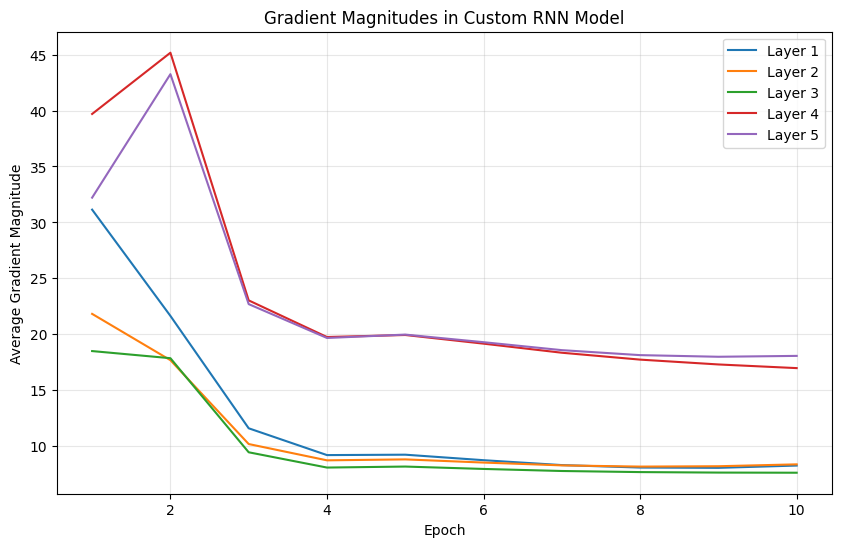

In [9]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

# Set random seeds for reproducibility
#np.random.seed(42)
#tf.random.set_seed(42)

# Generate some toy data
X = np.random.rand(1000, 10, 1)
y = np.random.randint(0, 2, size=(1000, 1))

# Define a custom RNN model (виправлений)
class CustomRNNModel(tf.keras.Model):
    def __init__(self, units, depth):
        super(CustomRNNModel, self).__init__()
        self.depth = depth
        self.rnn_layer = [tf.keras.layers.SimpleRNN(units, return_sequences=True) 
                         for _ in range(depth)]
        self.dense_layer = tf.keras.layers.Dense(1, activation='sigmoid')

    def call(self, inputs):
        states = inputs
        for i in range(self.depth):
            states = self.rnn_layer[i](states)
        outputs = self.dense_layer(states[:, -1, :])
        return outputs

# Create the custom RNN model
units = 10
depth = 5
model_rnn = CustomRNNModel(units, depth)

# Compile the model
model_rnn.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Define a function to compute gradients
def get_gradients(inputs, labels, model):
    with tf.GradientTape(persistent=True) as tape:
        predictions = model(inputs, training=True)
        loss = tf.keras.losses.binary_crossentropy(labels, predictions)
    gradients = tape.gradient(loss, model.trainable_variables)
    del tape
    return gradients

# Train the model and track gradients
num_epochs = 10
gradients_history = [[] for _ in range(depth)]

for epoch in range(num_epochs):
    model_rnn.fit(X, y, batch_size=32, epochs=1, verbose=0)
    gradients = get_gradients(X, y, model_rnn)
    
    # Збираємо градієнти для кожного RNN шару
    for i in range(depth):
        # Кожен RNN шар має 2 trainable variables (kernel, recurrent_kernel, bias)
        # Або перевірте точну структуру
        layer_grads = [g for j, g in enumerate(gradients) 
                      if j // 3 == i and g is not None]  # приблизне групування
        if layer_grads:
            avg_gradient_magnitude = np.mean([tf.norm(g).numpy() for g in layer_grads])
            gradients_history[i].append(avg_gradient_magnitude)

# Plot the gradient magnitudes
plt.figure(figsize=(10, 6))
for i in range(depth):
    plt.plot(range(1, num_epochs + 1), gradients_history[i], label=f'Layer {i+1}')
plt.xlabel('Epoch')
plt.ylabel('Average Gradient Magnitude')
plt.title('Gradient Magnitudes in Custom RNN Model')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


# GRU

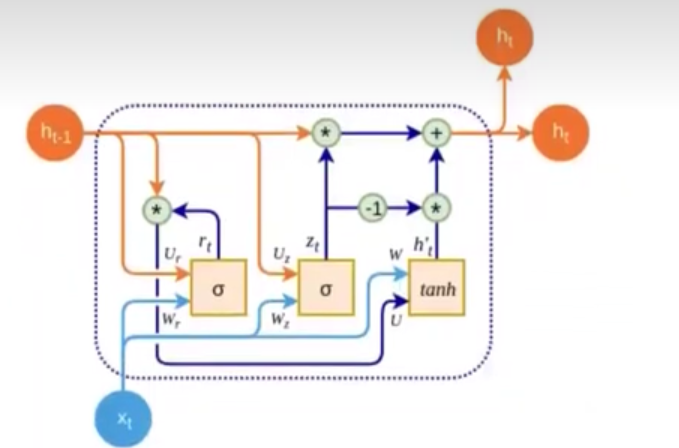


https://medium.com/@anishnama20/understanding-gated-recurrent-unit-gru-in-deep-learning-2e54923f3e2

https://d2l.ai/chapter_recurrent-modern/gru.html

https://github.com/kaustubhhivare/LSTM-GRU-from-scratch/blob/master/module.py